<a href="https://colab.research.google.com/github/mrunmayee3108/SciExpert/blob/main/ARC_clean_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARC-Challenge Dataset

In [ ]:
import json
import random
import re
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

INPUT_FILE = "ARC-Challenge-Train.jsonl"

with open(INPUT_FILE, "r") as f:
    raw_data = [json.loads(line) for line in f]

flat_records = []
for row in raw_data:
    flat_records.append({
        "id"        : row["id"],
        "question"  : row["question"]["stem"],
        "choices"   : row["question"]["choices"],
        "answerKey" : row["answerKey"]
    })

df = pd.DataFrame(flat_records)
len(df)

1119

In [ ]:
df.head()

,id,question,choices,answerKey
0,Mercury_SC_415702,George wants to warm his hands quickly by rubb...,"[{'text': 'dry palms', 'label': 'A'}, {'text':...",A
1,MCAS_2009_5_6516,Which of the following statements best explain...,"[{'text': 'The refrigerator door is smooth.', ...",B
2,Mercury_7233695,A fold observed in layers of sedimentary rock ...,"[{'text': 'cooling of flowing magma.', 'label'...",B
3,Mercury_7041615,Which of these do scientists offer as the most...,"[{'text': 'worldwide disease', 'label': 'A'}, ...",D
4,Mercury_7041860,A boat is acted on by a river current flowing ...,"[{'text': 'west', 'label': 'A'}, {'text': 'eas...",B


In [ ]:
df.shape

(1119, 4)

In [ ]:

print(df.isnull().sum())
print("\nUnique answerKey values:", df["answerKey"].unique())

id           0
question     0
choices      0
answerKey    0
dtype: int64

Unique answerKey values: ['A' 'B' 'D' 'C' '2' '4' '1' '3']


In [ ]:
# dropping duplicate questions
df = df.drop_duplicates(subset=["question"])
print("After drop_duplicates:", len(df))

After drop_duplicates: 1118


In [ ]:
# droppin null values
df = df.dropna(subset=["question", "answerKey", "choices"])
print("After dropna:", len(df))

After dropna: 1118


In [ ]:
# Keeping only rows with exactly 4 choices
df = df[df["choices"].apply(lambda x: len(x) == 4)]
print("After filtering to exactly 4 choices:", len(df))

After filtering to exactly 4 choices: 1116


In [ ]:
# Cleaning extra whitespace in question text
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)   # collapse multiple spaces/newlines into one space
    return text.strip()

df["question"] = df["question"].apply(clean_text)
print("Whitespace cleaned.")

Whitespace cleaned.


In [ ]:
# Translating numeric labels to letters

numeric_to_letter = {"1": "A", "2": "B", "3": "C", "4": "D"}

def translate_label(label):
    return numeric_to_letter.get(str(label), str(label))

df["answerKey"] = df["answerKey"].apply(translate_label)


def translate_choices(choices):
    return [{"text": c["text"], "label": translate_label(c["label"])} for c in choices]

df["choices"] = df["choices"].apply(translate_choices)

print("Unique answerKey values after translation:", df["answerKey"].unique())

Unique answerKey values after translation: ['A' 'B' 'D' 'C']


In [ ]:
df.head()

,id,question,choices,answerKey
0,Mercury_SC_415702,George wants to warm his hands quickly by rubb...,"[{'text': 'dry palms', 'label': 'A'}, {'text':...",A
1,MCAS_2009_5_6516,Which of the following statements best explain...,"[{'text': 'The refrigerator door is smooth.', ...",B
2,Mercury_7233695,A fold observed in layers of sedimentary rock ...,"[{'text': 'cooling of flowing magma.', 'label'...",B
3,Mercury_7041615,Which of these do scientists offer as the most...,"[{'text': 'worldwide disease', 'label': 'A'}, ...",D
4,Mercury_7041860,A boat is acted on by a river current flowing ...,"[{'text': 'west', 'label': 'A'}, {'text': 'eas...",B


In [ ]:


final_rows = []

for _, row in df.iterrows():
    choices = row["choices"]
    answer_key = row["answerKey"]

    # Build label → text lookup
    options = {c["label"]: c["text"] for c in choices}

    # Skip if any of A/B/C/D is missing (safety check)
    if not all(k in options for k in ["A", "B", "C", "D"]):
        continue

    formatted_text = (

        f"Question: {row['question']}\n\n"
        f"A. {options['A']}\n"
        f"B. {options['B']}\n"
        f"C. {options['C']}\n"
        f"D. {options['D']}\n\n"
        f"Answer:{answer_key}"
    )

    final_rows.append({
        "dataset_source": "ARC-Challenge",
        "text"          : formatted_text,
        "answer_key"    : answer_key
    })

clean_df = pd.DataFrame(final_rows)


In [ ]:
clean_df.head()

,dataset_source,text,answer_key
0,ARC-Challenge,Question: George wants to warm his hands quick...,A
1,ARC-Challenge,Question: Which of the following statements be...,B
2,ARC-Challenge,Question: A fold observed in layers of sedimen...,B
3,ARC-Challenge,Question: Which of these do scientists offer a...,D
4,ARC-Challenge,Question: A boat is acted on by a river curren...,B


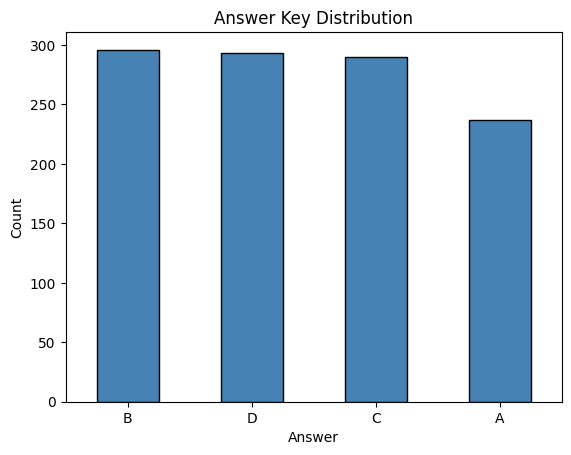

In [ ]:

clean_df["answer_key"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Answer Key Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

##### answers are balanced over all 4 options

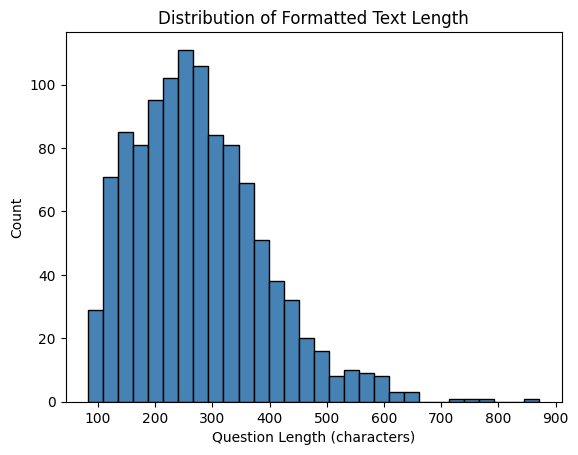

In [ ]:

ques_len = clean_df["text"].str.len()
plt.hist(ques_len, bins=30, color="steelblue", edgecolor="black")
plt.xlabel("Question Length (characters)")
plt.ylabel("Count")
plt.title("Distribution of Formatted Text Length")
plt.show()

###### almost questn are of len 250 - 320 some go upto 650 very few go as long as 850

In [ ]:
ques_len.describe()

,text
count,1116.000000
mean,276.853943
std,114.361214
min,83.000000
25%,191.000000
50%,264.000000
75%,342.000000
max,871.000000


##### len of questn isnt related much to our answerkey column




In [ ]:
OUTPUT_FILE = "arc_clean.csv"
clean_df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(clean_df)} rows to {OUTPUT_FILE}")

Saved 1116 rows to arc_clean.csv
